In [53]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

# Clustering with K-means

In this exercise we revisit the k-means algorithm. First you will implement the algorithm and run it on a Gaussian mixture toy-dataset, then apply it to a dataset of pulsar candidate observations.   

### 1) Gaussian mixture data
Write a function which generates toy-data drawn from a Gaussian mixture model. The samples are drawn from $k$ Gaussian clusters of random means and uniform covariance $\Sigma = \text{std\_dev} \times \mathbb{I}_{dxd}$. Each cluster has `samples_per_component` elements, and its mean is sampled randomly from the uniform distribution

In [54]:
def generate_gaussian_mixture_data(
    k: int,
    samples_per_component: int,
    d: int = 2,
    mean_range: tuple = (-10, 10),
    std_dev: float = 1.0
) -> np.ndarray:
    """
    Generate data from a Gaussian mixture model.

    Parameters:
        - k : Number of Gaussian components.
        - samples_per_component : Number of samples per component.
        - d : Dimension of each gaussian.
        - mean_range : Tuple (a, b), each coordinate of each mean is drawn uniformly from [a, b].
        - std_dev : Standard deviation for each component.

    Returns:
        numpy.ndarray of shape (k * samples_per_component, d).
    """
    data = []

    # Generate one Gaussian per component
    for _ in range(k):
        # Sample a mean vector in R^d
        mean = np.random.uniform(mean_range[0], mean_range[1], size=d)
        # Generate samples around that mean
        samples = np.random.normal(loc=mean, scale=std_dev, size=(samples_per_component, d))
        data.append(samples)

    return np.vstack(data)

Draw a $d = 2$ dataset with some $k\sim \mathcal{O}(1)$ and plot the data points in the 2-dimensional space.

Generated data shape: (500, 2)


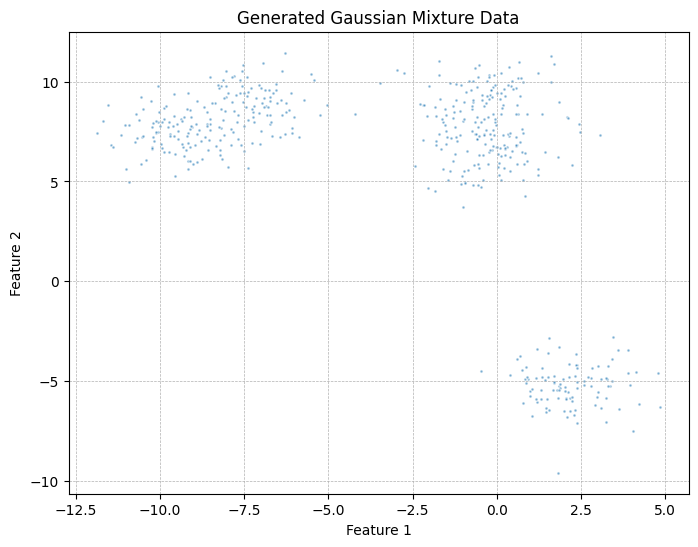

In [55]:
# hyperparameters
k = 5
samples_per_component = 100

datas = generate_gaussian_mixture_data(k, samples_per_component)
print("Generated data shape:", datas.shape)

# visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(datas[:, 0], datas[:, 1], alpha=0.6, edgecolors='w', s=5)
plt.title('Generated Gaussian Mixture Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### 2) K-means implementation

Implement the k-means algorithm. Return the estimated cluster means and cluster asssignments of each iteration, not only the final state.

Your algorithm should stop after `max_iters` iterations or when the change in the means of the clusters $$ \sum_{i = 1}^k \| \mu_i^{t+1} - \mu_i^{t} \|^2$$ is less than `tol`.

In [56]:
def kmeans(data : np.ndarray, k, max_iters : int =100, tol=1e-3):
    """
    Implements the K-Means clustering algorithm and tracks the history of centroids and assignments.

    Parameters:
        - data : n x d matrix containing the data points
        - k    : Number of clusters.
        - max_iters (int): Maximum number of iterations.
        - tol (float): Iteration stops if all centroids have moved less than tol

    Returns:
        - final_centroids, final_cluster_assignments, centroids_history, assignments_history)
    """ 
    # 1) Create empty lists to append centroids and assignments (cluster index of each data point) from each iteration
    centroids_history   = []
    # assignments_history[i][j] = k if at iteration i, cluster of j is k
    assignments_history = []
    
    # 2) Randomly initialize the centroids 
    n, d = data.shape
    random_indices = np.random.choice(n, size=k, replace=False)
    centroids = data[random_indices]

    for _ in range(max_iters):
        pass
        # 3) Assign data points to the nearest centroid
        dataset_distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        cluster_assignments = np.argmin(dataset_distances, axis=1)
        # 4) Update the centroids
        centroids_new = np.array([data[cluster_assignments == ki].mean(axis=0) for ki in range(k)])
        # 5) Check for convergence and if the the centroids move less than tol, break
        if np.linalg.norm(centroids_new - centroids) < tol:
            break
        # Assign data points to final centroids
        centroids = centroids_new
        # Store history
        centroids_history.append(centroids.copy())
        assignments_history.append(cluster_assignments.copy())
    return centroids, cluster_assignments, centroids_history, assignments_history


Apply your implementation to the Gaussian mixture toy-data, and use the provided ```plot_kmeans_iterations()``` function to visualize how centroids and cluster assignments evolve over the iterations.  
If you like, play around with the number of clusters in the data and in the algorithm, or vary how well-seperated the data clusters are, and observe the k-means dynamics. Do you notice failure modes?

In [57]:
import matplotlib.pyplot as plt

def plot_kmeans_iterations(data, centroids_history, assignments_history):
    """
    Plots K-Means iterations showing centroids and data point assignments.

    Parameters:
    data (np.array of shape (n_samples,2)): Data points.
    centroids_history (list of (k,2) shape np.arrays): List of the centroids at each iteration.
    assignments_history (list of (k) shape np.arrays): List of data point assignments at each iteration.
    """
    n_iters = len(centroids_history)
    plt.figure(figsize=(15, 5 * n_iters))

    for i in range(n_iters):
        plt.subplot(n_iters, 1, i + 1)
        plt.scatter(data[:, 0], data[:, 1], c=assignments_history[i], alpha=0.5, marker='.')
        plt.scatter(centroids_history[i][:, 0], centroids_history[i][:, 1], c='red', marker='X')
        plt.title(f'Iteration {i+1}')
        plt.xlabel('X')
        plt.ylabel('Y')

    plt.tight_layout()
    plt.show()


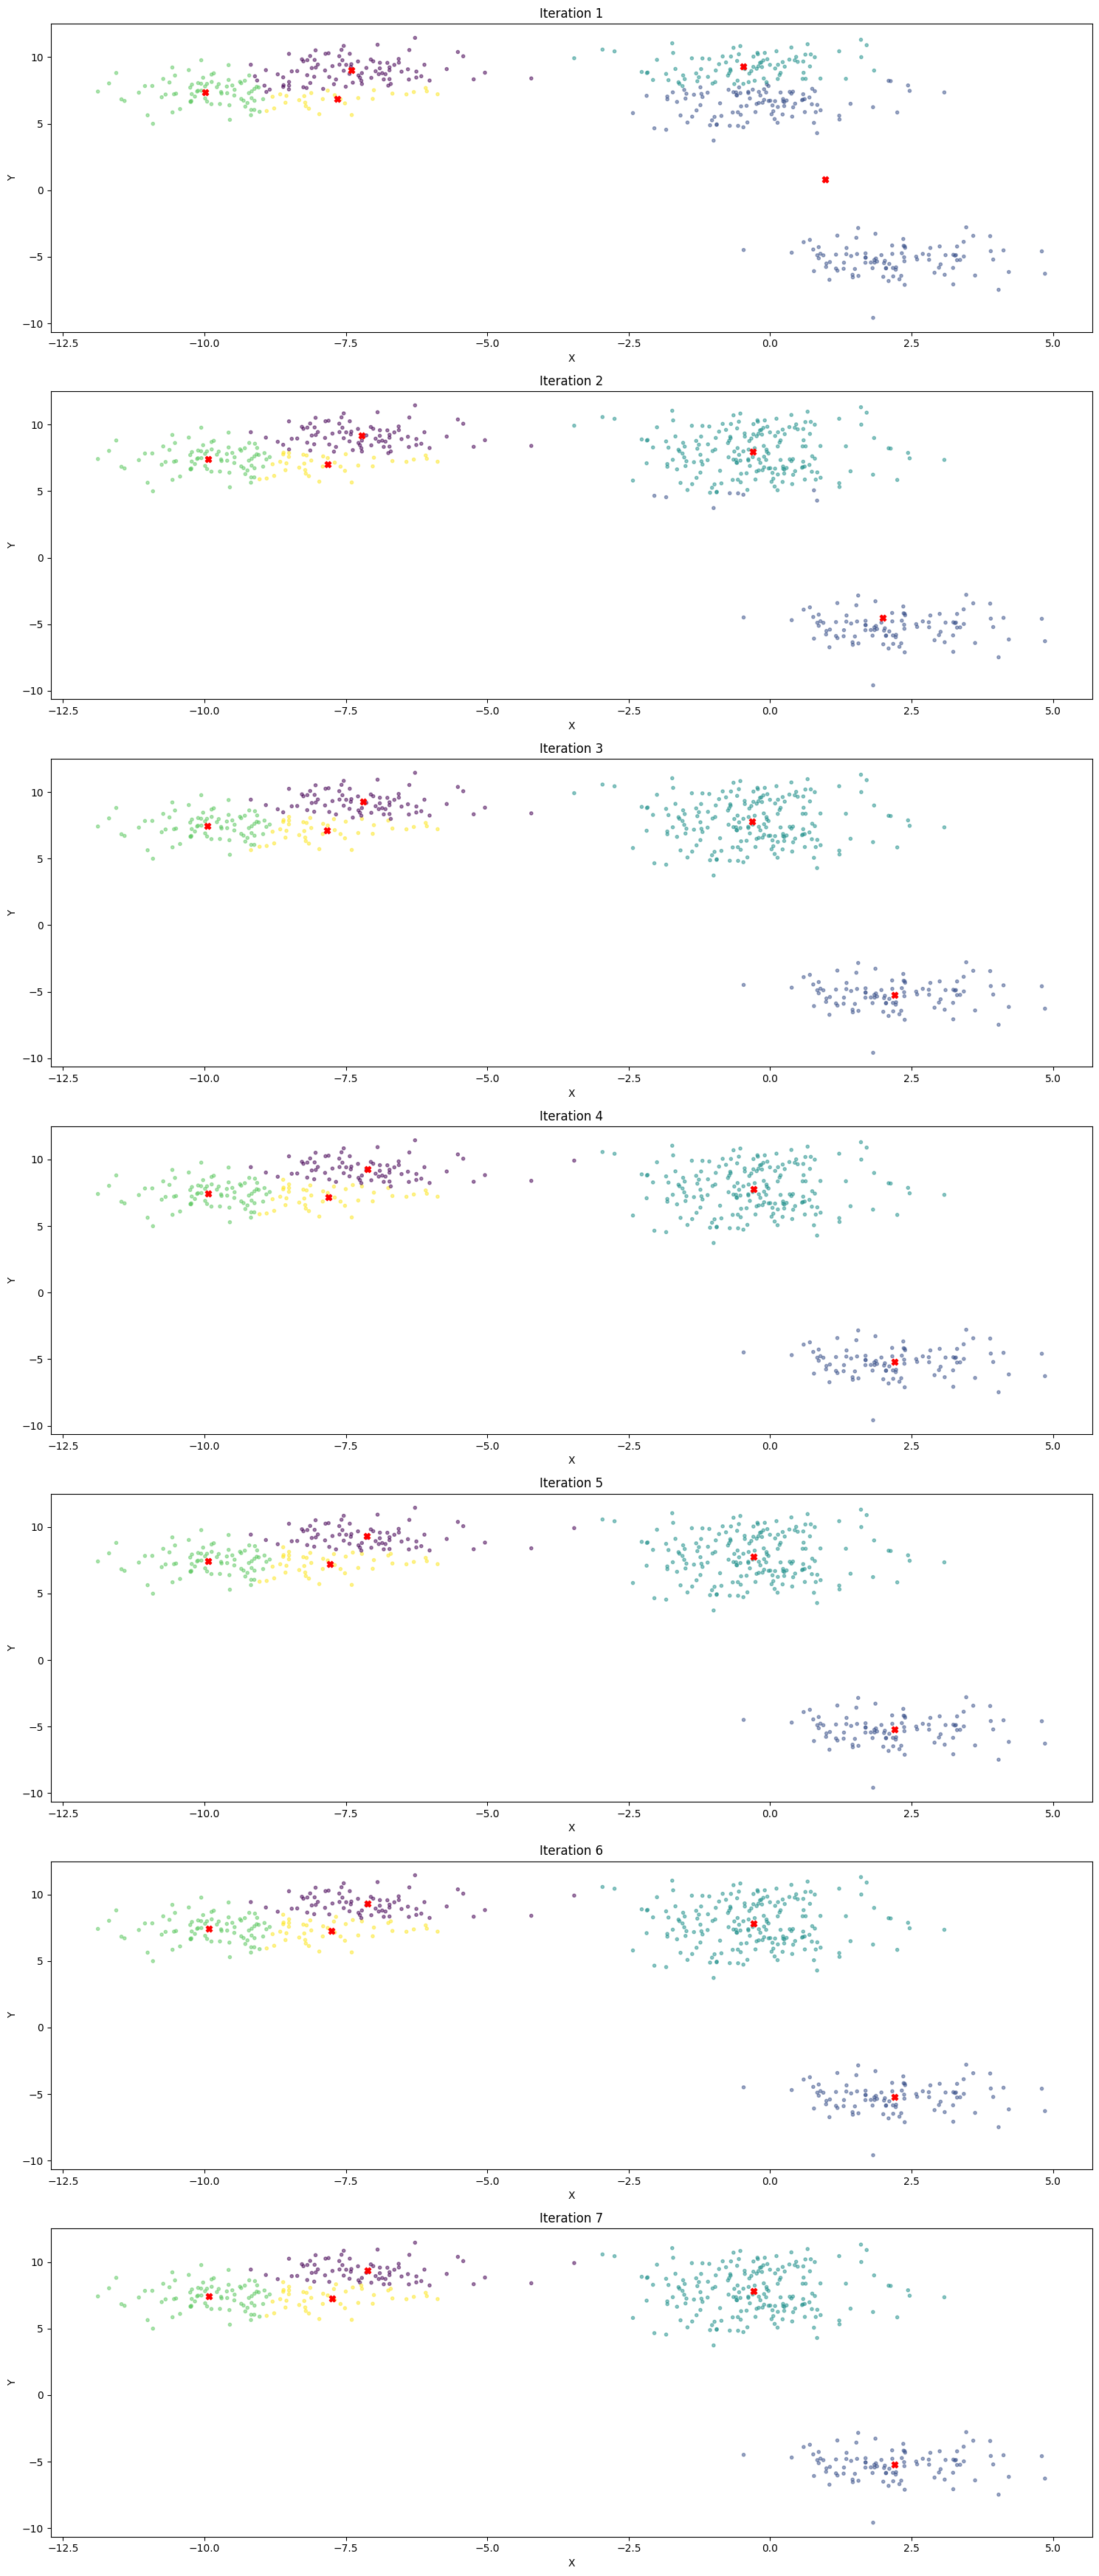

In [58]:
# apply kmeans() to the toy-data and plot the iterations.
centroids, cluster_assignments, centroids_history, assignments_history = kmeans(datas, k)

plot_kmeans_iterations(datas, centroids_history, assignments_history)

### 3) Clustering of pulsar observation data
We now consider a dataset of pulsar candidates from the HTRU survey. You can download the data and read the description of the data on the [UCI machine learning repository](https://archive.ics.uci.edu/dataset/372/htru2). The .csv file is also provided on Moodle with the exercise. Our goal is to see in how far pulsars and false pulsar candidates are represented by two different clusters which we can automatically discover via clustering. While this is a very simple method, k-means has been applied extensively in scientific data analysis, for an example from astrophysics similar to our pulsar candidate clustering here, see [Turner et al. 2019](https://academic.oup.com/mnras/article/482/1/126/5116177) who are clustering galaxy survey data. But now to the pulsar candidates.  


Read the description and familiarize yourself with the data. Load it from the ```.csv``` file, for example using ```np.loadtxt()```, then investigate some basic questions such as:*
- *How many samples and features are there?*
- *What is the mean and variance of the different features?*
- *How many true pulsars and how many non-pulsars are in the data?*

Shape of datas : (17898, 9)
Number of samples: 17898
Number of features: 8 (last column is label)
Feature 1: mean = 111.080, variance = 658.036
Feature 2: mean = 46.550, variance = 46.827
Feature 3: mean = 0.478, variance = 1.132
Feature 4: mean = 1.770, variance = 38.041
Feature 5: mean = 12.614, variance = 868.603
Feature 6: mean = 26.327, variance = 379.082
Feature 7: mean = 8.304, variance = 20.304
Feature 8: mean = 104.858, variance = 11344.713
Number of pulsars: 1639
Number of non-pulsars: 16259


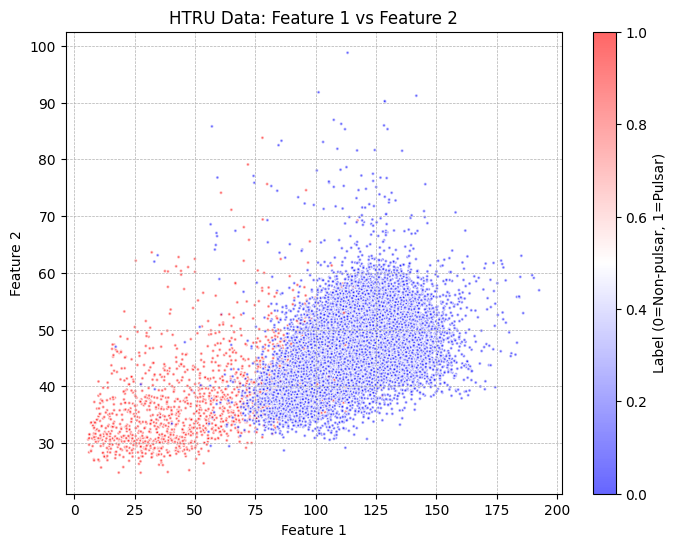

In [68]:
# Load the data 
datas_HTRU = np.loadtxt('HTRU_2.csv', delimiter=',')
print(f"Shape of datas : {datas_HTRU.shape}")

n_samples, n_features = datas_HTRU.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features - 1} (last column is label)")

features = datas_HTRU[:, :-1]  # toutes les colonnes sauf la dernière
means = np.mean(features, axis=0)
variances = np.var(features, axis=0)

for i, (m, v) in enumerate(zip(means, variances), 1):
    print(f"Feature {i}: mean = {m:.3f}, variance = {v:.3f}")

labels = datas_HTRU[:, -1]  # dernière colonne
n_pulsars = np.sum(labels == 1)
n_non_pulsars = np.sum(labels == 0)
print(f"Number of pulsars: {n_pulsars}")
print(f"Number of non-pulsars: {n_non_pulsars}")

plt.figure(figsize=(8, 6))
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='bwr', alpha=0.6, edgecolors='w', s=5)
plt.title('HTRU Data: Feature 1 vs Feature 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.colorbar(label='Label (0=Non-pulsar, 1=Pulsar)')
plt.show()

Remove the column containing the labels, since we want to do unsupervised learning. The ground-truth labels will be used later to assess our clustering result.*
* Before using  k-means on the data, preprocess the data by standardizing it, e.g. ```sklearn.preprocessing.StandardScaler```?

In [71]:
features_stand = sklearn.preprocessing.StandardScaler().fit_transform(features)
centroids, cluster_assignments, centroids_history, assignments_history = kmeans(features_stand, k = 2)

Look for the k-means implementation in sklearn and apply it to the data. Use n_clusters=2.*

In [73]:
# doc : https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
kmeans = sklearn.cluster.KMeans(n_clusters=2).fit(features_stand)

Get the cluster assignment of each sample. We want to compare these to the true labels and evaluate the performance of our clustering. To do so, we'll use the [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) from `sklearn`

Accuracy (original labels): 0.15700078221030284


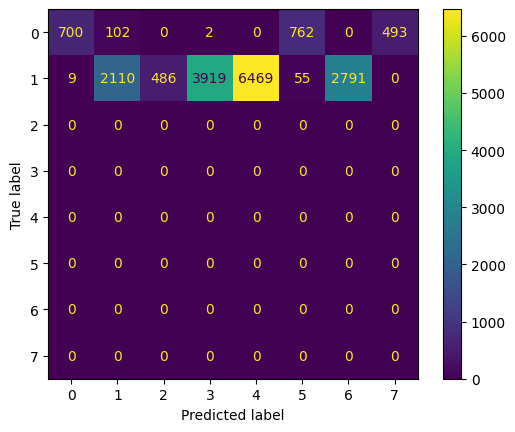

In [78]:
# Get the cluster assignments and the true labels, then print the confusion matrix
y_true = kmeans.labels_
y_pred = cluster_assignments
conf_matrix = sklearn.metrics.confusion_matrix(y_true, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot()
# Also print the accuracy of the clustering (the labels may need to be flipped)
accuracy_score = sklearn.metrics.accuracy_score(y_true, y_pred)
accuracy_score_flipped = sklearn.metrics.accuracy_score(y_true, 1 - y_pred)
print("Accuracy (original labels):", accuracy_score)

Use the plotting function provided below, and inspect the resulting 2d slices of the clusters colored by cluster index and true label. Read through the function to see how it handles the coloring and plotting.

In [63]:
def plot_pulsar_clusters_vs_labels(X, y, y_pred):
    """
    Plots the results of k-means clustering against actual labels.

    This function visualizes the comparison between k-means clustering predictions 
    (y_pred) and actual labels (y) for each pair of features in the dataset. 
    It uses different colors to indicate true positives, true negatives, false negatives,
    and false positives.

    Parameters:
    X (numpy.ndarray): The feature data set. Each row represents a sample, 
                       and each column represents a feature.
    y (numpy.ndarray): The actual labels for each sample. This array is 1-dimensional.
    y_pred (numpy.ndarray): The predicted labels from k-means clustering. 
                            This array is 1-dimensional.

    The function creates scatter plots for each pair of features in the data set.
    """
    
    feature_names = ['Mean of the integrated profile',
                     'Standard deviation of the integrated profile',
                     'Excess kurtosis of the integrated profile',
                     'Skewness of the integrated profile',
                     'Mean of the DM-SNR curve',
                     'Standard deviation of the DM-SNR curve',
                     'Excess kurtosis of the DM-SNR curve',
                     'Skewness of the DM-SNR curve']

    # making a coloring array for scatterplots
    lightred = np.array([0.9, 0, 0])
    red = np.array([0.4, 0, 0])
    yellow = np.array([0.9, 0.9, 0])
    blue = np.array([0, 0, 0.9])

    data_coloring = np.zeros((y.size, 3))
    data_coloring[(y_pred == 1) & (y == 1)] = yellow  # True positive
    data_coloring[(y_pred == 0) & (y == 0)] = blue    # True negative
    data_coloring[(y_pred == 0) & (y == 1)] = red     # False negative
    data_coloring[(y_pred == 1) & (y == 0)] = lightred # False positive

    for i in range(4):
        dims = [2 * i, 2 * i + 1]
        plt.figure(figsize=(8, 6))
        plt.title('k-means prediction vs. label')
        plt.scatter(X[:, dims[0]], X[:, dims[1]], c=data_coloring, marker='.', alpha=0.6)
        plt.xlabel(feature_names[dims[0]])
        plt.ylabel(feature_names[dims[1]])

        # Adding legend
        plt.scatter([], [], color=yellow, label='True Positive')
        plt.scatter([], [], color=blue, label='True Negative')
        plt.scatter([], [], color=red, label='False Negative')
        plt.scatter([], [], color=lightred, label='False Positive')
        plt.legend()

        plt.show()


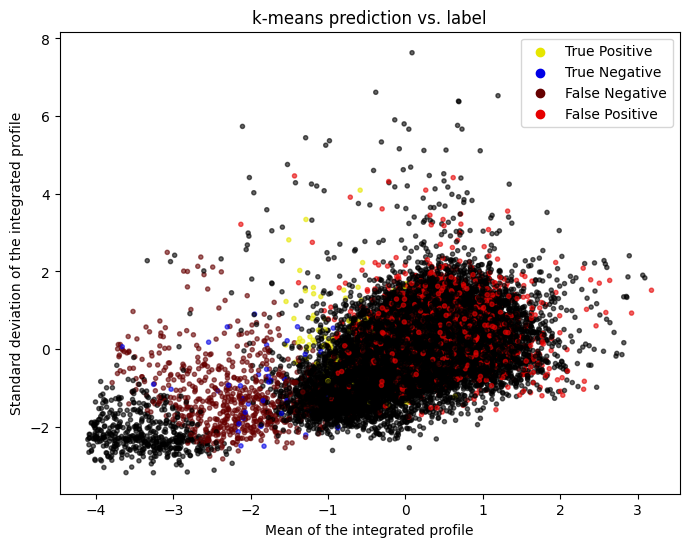

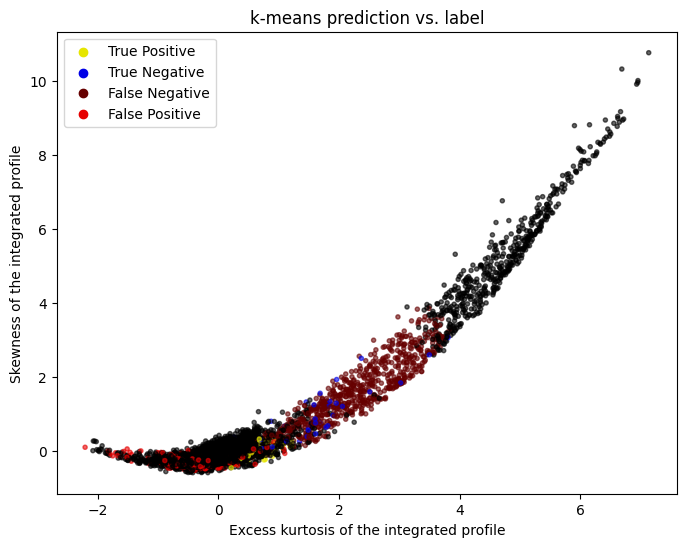

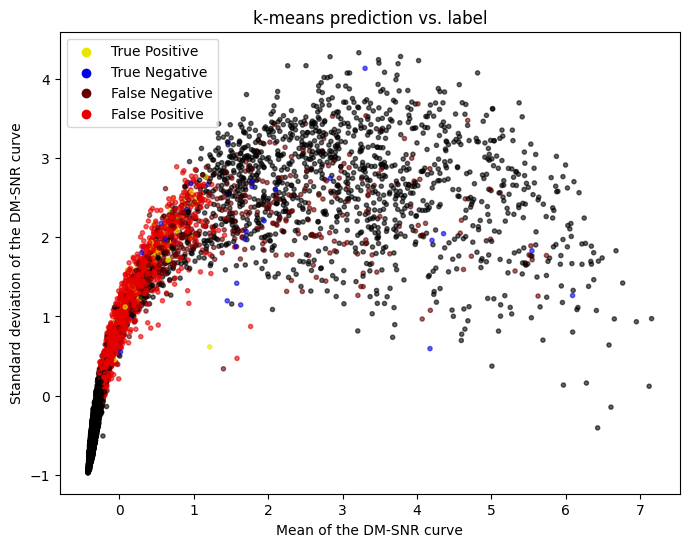

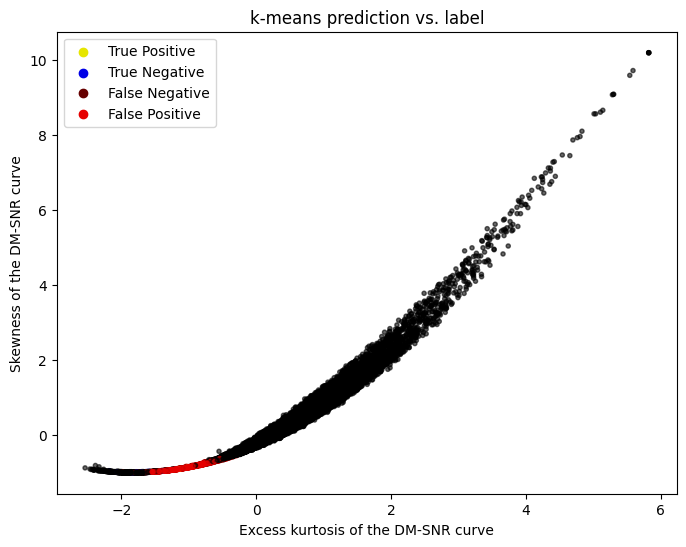

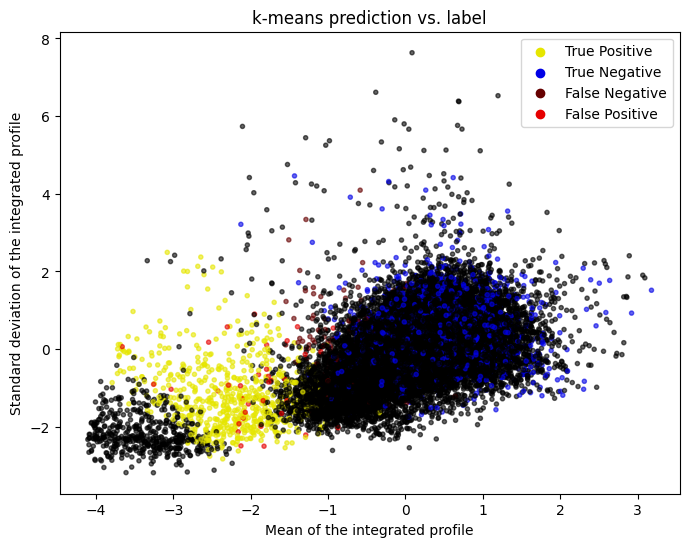

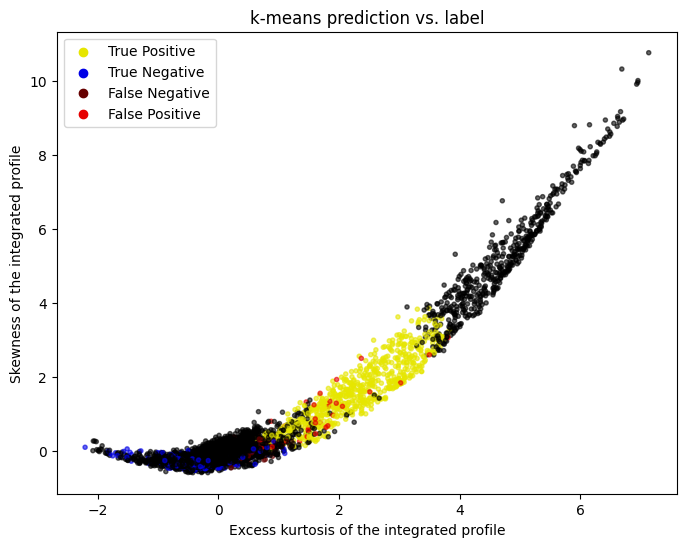

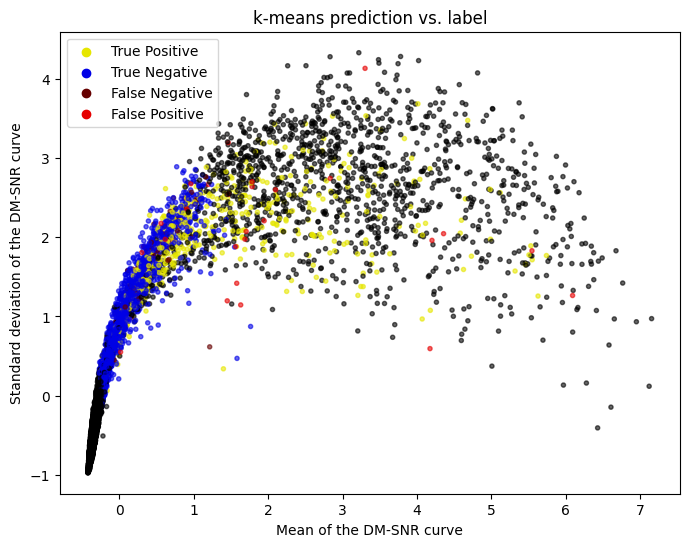

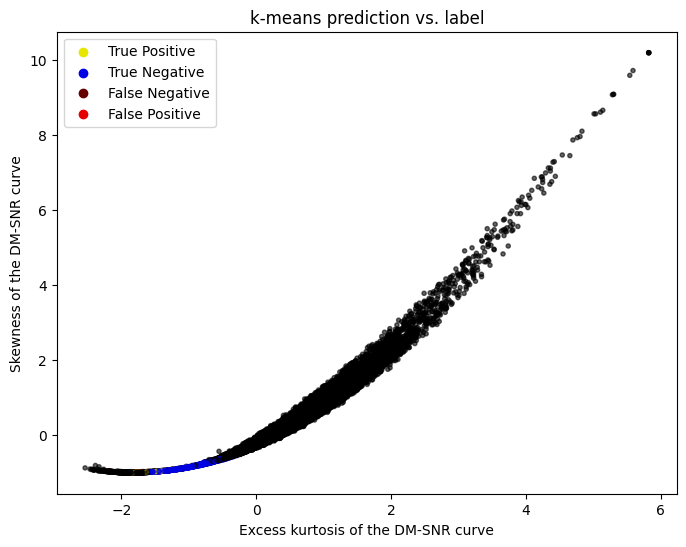

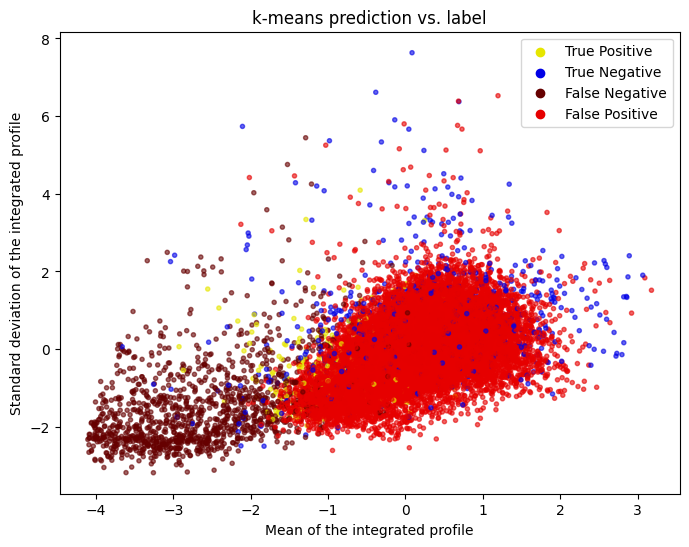

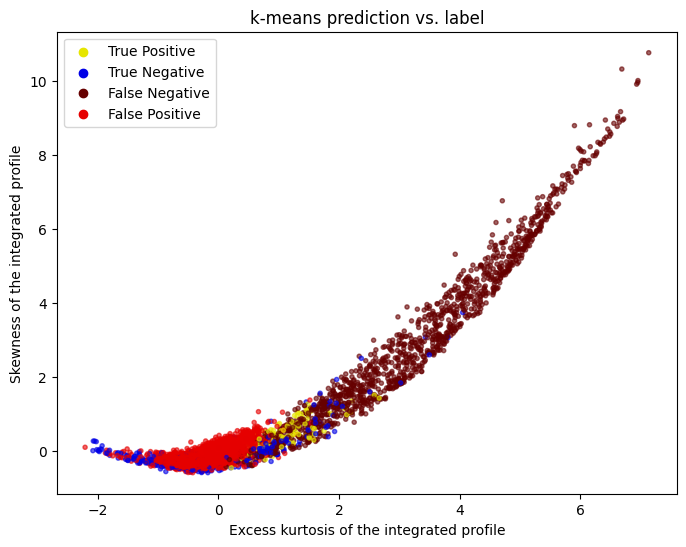

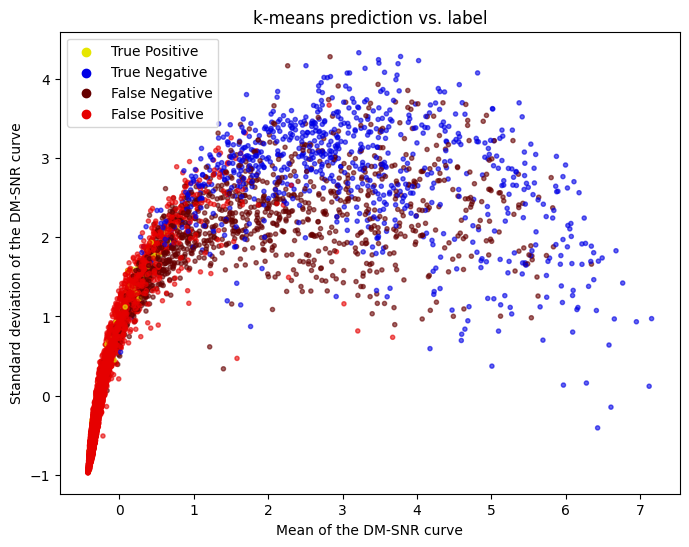

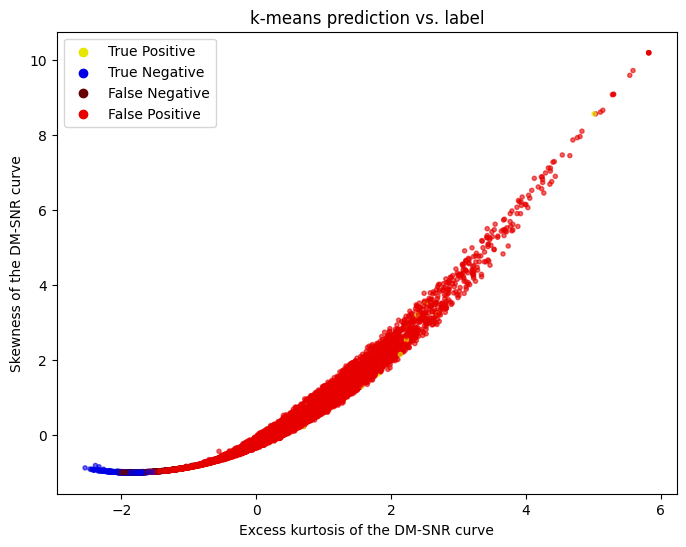

In [76]:
# Call plot_pulsar_clusters_vs_labels()
# In case the kmeans 0 labels correspond best to the ground truth 1 label, flip them if you have not done already

plot_pulsar_clusters_vs_labels(features_stand, labels, cluster_assignments)
plot_pulsar_clusters_vs_labels(features_stand, labels, 1 - cluster_assignments)
plot_pulsar_clusters_vs_labels(features_stand, labels, kmeans.labels_)